In [1]:
import pandas as pd
data=pd.read_csv("TATACOFFEE13_21.csv")
data

,Date,Open,High,Low,Close
0,2013-01-01,1410.60,1427.90,1408.30,1415.10
1,2013-01-02,1421.00,1626.60,1416.15,1607.40
2,2013-01-03,1632.55,1673.90,1613.05,1626.20
3,2013-01-04,1627.75,1627.75,1574.60,1579.05
4,2013-01-07,1580.00,1639.50,1565.50,1595.65
...,...,...,...,...,...
2220,2021-12-22,202.90,207.80,201.35,205.00
2221,2021-12-23,206.00,206.85,202.05,202.95
2222,2021-12-24,203.90,203.90,199.35,201.00
2223,2021-12-27,200.00,222.00,196.00,218.35


In [2]:
column = "Close"

from sklearn.preprocessing import MinMaxScaler

Ms = MinMaxScaler()

data1 = Ms.fit_transform(data[[column]])

print("Len:", data1.shape)

Len: (2225, 1)


In [3]:
training_size = round(len(data1) * 0.95)

print(training_size)

X_train = data1[:training_size]
X_test = data1[training_size:]

print("X_train length:", X_train.shape)
print("X_test length:", X_test.shape)

y_train = data1[:training_size]
y_test = data1[training_size:]

print("y_train length:", y_train.shape)
print("y_test length:", y_test.shape)

2114
X_train length: (2114, 1)
X_test length: (111, 1)
y_train length: (2114, 1)
y_test length: (111, 1)


In [4]:
orders = [(0,0,0), (0,0,1), (2,0,1), (1,1,1)]
orderlist = []

from statsmodels.tsa.statespace.sarimax import SARIMAX

for i in orders:

    orderlist.append(i)

    model = SARIMAX(
        data1,
        order=i,
        seasonal_order=(0,0,0,12)
    )

    model_fit = model.fit()

    # make prediction
    y_pred = model_fit.predict(
        0,
        len(data1)-1
    )

    print(i)

    from stockFunctions import rmsemape

    rmsemape(data1, y_pred)

    print("****************")

(0, 0, 0)
RMSE-Testset: 0.32396689611601376
MAPE-Testset: 0.9995505617977528
****************


D:\Users\admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


(0, 0, 1)
RMSE-Testset: 0.16808411303944915
MAPE-Testset: 3455747589.4809866
****************
(2, 0, 1)
RMSE-Testset: 0.022872630233257137
MAPE-Testset: 2362967158.087551
****************
(1, 1, 1)
RMSE-Testset: 0.02288594565997708
MAPE-Testset: 2377525502.6205482
****************


D:\Users\admin\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


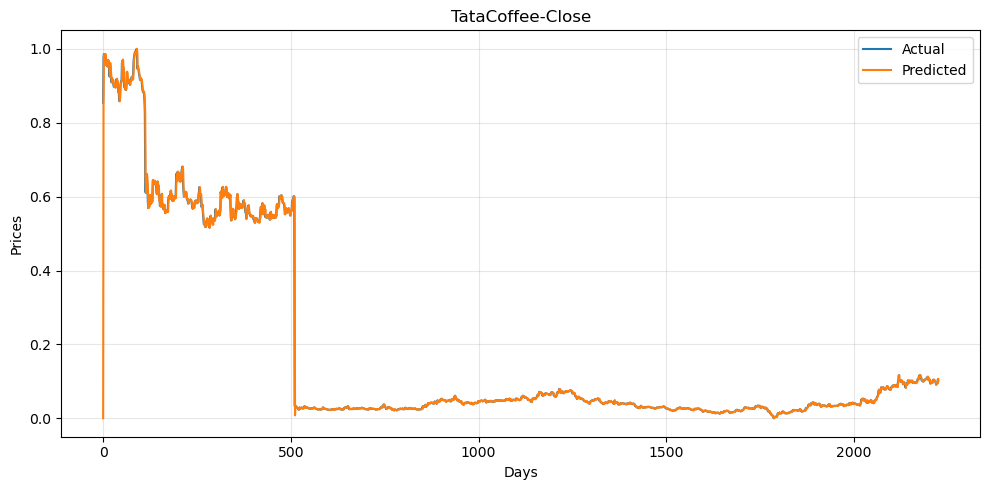

In [5]:
from stockFunctions import graph

graph(
    data1,
    y_pred,
    "Actual",
    "Predicted",
    "TataCoffee-Close",
    "Days",
    "Prices"
)